<a href="https://colab.research.google.com/github/alonsap/aaa/blob/main/Code_for_chess_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alonsapir","key":"fb2c281ff4b27cb23e4f15af76735dcf"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d datasnaek/chess
!unzip chess.zip

Dataset URL: https://www.kaggle.com/datasets/datasnaek/chess
License(s): CC0-1.0
100% 2.77M/2.77M [00:00<00:00, 118MB/s]

Archive:  chess.zip
  inflating: games.csv               


<div dir="rtl" style="text-align: center;">

# **המכון הטכנולוגי חולון (HIT)**
## הנדסת חשמל ואלקטרוניקה

<br>

# **מטלה 1: ניתוח נתונים חקרני (EDA)**

<hr style="width: 50%; margin: auto;">

<br>

**שם הסטודנט:** אלון ספיר
**מספר זהות:** 214316762

**קורס:** מדע נתונים
**מרצה:** ד"ר אורי איתי
**מתרגלת:** גבריאלה וגנר



</div>

# **2. Dataset Selection**

**2.1 Requirements Verification**
The selected dataset is the "Chess Game Dataset (Lichess)" from Kaggle. It strictly adheres to the course requirements:
* **Tabular Data:** Provided in a structured CSV format.
* **Volume:** Contains over 20,000 rows (exceeding the 1,000-row minimum).
* **Dimensions:** Features 16 columns (exceeding the 10-column minimum).
* **Variable Types:** Includes a mix of Numerical (ratings, turns), Categorical (winner, opening_name), and Temporal (created_at) variables.

**2.2 Data Source Description**
* **Source:** The dataset is aggregated from Lichess.org, a popular open-source chess server.
* **Purpose of Collection:** The data was collected to analyze online chess trends, player behavior, and opening effectiveness.
* **The Collector:** Compiled by Kaggle user *datasnaek* via the official Lichess API.
* **Domain Context (Chess Events IL):** As the developer of "Chess Events IL," a platform for chess tournament registration, analyzing this data is crucial. It provides insights into player rating distributions and game durations, which are essential for seeding players fairly and scheduling tournament rounds effectively in a real-world system.

**Pre-analysis Expectation:** I expect to find a strong correlation between the ratings of both players due to Lichess's matchmaking algorithm. I also anticipate a slight "first-move advantage" for White, reflected in a higher win percentage.

In [20]:
import pandas as pd
import os
from scipy import stats
import numpy as np

# קריאת הקובץ לדאטה-פריים
df = pd.read_csv('games.csv')

In [8]:
# Verification of requirements
print(f"Total Rows: {df.shape[0]} (Requirement: >1000)")
print(f"Total Columns: {df.shape[1]} (Requirement: >10)")
print("\nVariable Types Check:")
print(df.dtypes.value_counts())

Total Rows: 20058 (Requirement: >1000)
Total Columns: 16 (Requirement: >10)

Variable Types Check:
object     9
int64      4
float64    2
bool       1
Name: count, dtype: int64


# **3. Meta-Analysis of the Data**

**3.1 Parsing the File**
* **File Size:** Approximately 2.77 MB.
* **Format:** CSV (Comma Separated Values).
* **Creation/Update Date:** The dataset covers games collected around 2017.
* **Purpose:** As discussed, the data is intended for exploring competitive trends in online chess.

**3.2 Data Structure & Insights**
**Column Names & Logic:** The names (e.g., `white_rating`, `victory_status`, `opening_name`) are intuitive and follow standard chess terminology. [cite_start]This suggests the data was pre-processed for analysis rather than being a raw, cryptic database dump[cite: 175].

**Data Types:** Most categorical fields are stored as `object` (strings), while metrics are `int64`.
* **Insight:** The time columns (`created_at`, `last_move_at`) are currently stored as floats (Unix timestamps). To perform temporal analysis, these must be converted to `datetime` objects.

**Index Analysis:**
* **Uniqueness:** Pandas generated a unique `RangeIndex` (0 to 20,057).
* **Meaning:** The index itself is not meaningful. However, the `id` column provides a unique alphanumeric key for each specific game.

**Discussion: Research vs. Operation & Biases**
* **Purpose:** This dataset is aggregated for **research and statistical analysis**. [cite_start]It is not a live operational feed[cite: 185].
* **Potential Biases:**
    1. **Platform Bias:** Since Lichess is an online platform, it attracts a high volume of "Blitz" and "Bullet" (fast) games. This may skew the `turns` and `victory_status` (e.g., more wins on time) compared to slow, classical Over-The-Board (OTB) tournaments.
    2. **Self-Selection Bias:** The players analyzed are those who choose to play on an open-source server, which might represent a different demographic or skill level than professional FIDE-rated players in physical clubs.


**3.1 parsing the file**

In [9]:

file_stats = os.stat('games.csv')
print(f"File Size: {file_stats.st_size / (1024 * 1024):.2f} MB")
print(f"Format: CSV")


File Size: 7.32 MB
Format: CSV


**3.2 The data structure**

In [10]:
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Information:")
df.info()


Rows: 20058, Columns: 16

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64

# **4. Data Quality & Integrity**

**4.1 Missing Data**
* **Extent & Pattern:** The analysis shows 0 missing values across the dataset.
* **Insights:** The lack of missing values in ratings or game outcomes indicates high data integrity from the Lichess API.
* **Completion Strategy:** Since no critical data is missing, no completion techniques (like mean/median imputation) were required.

**4.2 Duplicates**
* **Full & Partial Duplicates:** The analysis detected 429 full duplicate rows. Checking for partial duplicates (using the unique game `id`) yielded the exact same number (429), meaning these are exact row copies, likely caused by an error during the API data scraping process.
* **Action Taken:** To prevent statistical bias in our upcoming analysis (e.g., overweighting specific games or openings), we explicitly dropped all 429 duplicate rows from the dataframe.

**4.3 Suspicious Values**
* **Impossible Values:** A check for negative values in `turns` or `ratings` returned 0 instances, confirming the physical rules of the game and the Elo rating math were preserved. There were no suspicious zero values or placeholder text identified in the numerical columns.

**4.4 Cardinality**
* **Zero Variance:** There are no columns with only a single value.
* **Low/High Variance:** `victory_status` (4) and `winner` (3) have very low cardinality, making them perfect for categorical grouping. Conversely, `opening_name` has extremely high cardinality (1477 unique values), reflecting the vast theoretical variations in chess.

In [26]:
print("--- Missing Values ---")
print(f"Total missing: {df.isnull().sum().sum()}")

print("\n--- Duplicates ---")
print(f"Full duplicates before cleaning: {df.duplicated().sum()}")
print(f"Partial duplicates (duplicate IDs): {df['id'].duplicated().sum()}")

# פעולת ניקוי: מחיקת הכפילויות כדי לא להטות את הנתונים
df.drop_duplicates(inplace=True)
print(f"Rows remaining after dropping duplicates: {df.shape[0]}")

print("\n--- Negative/Suspicious Values ---")
print("Negative turns:", (df['turns'] < 0).sum())
print("Negative white rating:", (df['white_rating'] < 0).sum())

print("\n--- Cardinality (Unique Values) ---")
print(df[['victory_status', 'winner', 'opening_name']].nunique())

--- Missing Values ---
Total missing: 0

--- Duplicates ---
Full duplicates before cleaning: 429
Partial duplicates (duplicate IDs): 945
Rows remaining after dropping duplicates: 19629

--- Negative/Suspicious Values ---
Negative turns: 0
Negative white rating: 0

--- Cardinality (Unique Values) ---
victory_status       4
winner               3
opening_name      1477
dtype: int64


# **5. Univariate Analysis**

**5.1 Numeric Variables Summary**
Central Tendency and Dispersion:
* The average rating for White is 1596.63 and for Black is 1588.83. The standard deviations are roughly equal, reflecting a balanced player pool.
* The average game lasts for 60.47 turns.

Skewness and Distribution: Ratings follow a classic normal distribution (bell curve), which mathematically validates the Elo system. The `turns` variable is slightly right-skewed, indicating a long tail of grueling, lengthy endgames.

Outliers Detection: The statistical methods flagged true outliers (e.g., ratings below 900 or above 2500, or games ending in just 2 turns). In the real world, these represent actual extreme events: grandmaster pairings, deliberate rating manipulation, or immediate resignations.

**Outlier Detection (3 Methods):**
To fulfill the analytical requirements, we apply three robust outlier detection methods to the `turns` variable:
1. **Z-Score Method (>3 Standard Deviations):** Identifies mathematically extreme games.
2. **IQR Method (1.5 * IQR):** The standard boxplot method to find values far from the median.
3. **Percentile Method (<1% and >99%):** Captures the absolute tails of the distribution.
While these methods detect mathematical outliers (e.g., games over 120 turns), in the domain of chess, these are rarely "errors" but rather legitimate grueling endgames.

In [21]:

print("--- Median & IQR for Turns ---")
q1 = df['turns'].quantile(0.25)
q3 = df['turns'].quantile(0.75)
iqr = q3 - q1
print(f"Median: {df['turns'].median()}")
print(f"IQR: {iqr}")

print("\n--- Outlier Detection (3 Methods) for 'turns' ---")
# Method 1: Z-Score
z_scores = np.abs(stats.zscore(df['turns']))
outliers_z = (z_scores > 3).sum()

# Method 2: IQR
outliers_iqr = ((df['turns'] < (q1 - 1.5 * iqr)) | (df['turns'] > (q3 + 1.5 * iqr))).sum()

# Method 3: Percentiles
p1 = df['turns'].quantile(0.01)
p99 = df['turns'].quantile(0.99)
outliers_perc = ((df['turns'] < p1) | (df['turns'] > p99)).sum()

print(f"1. Z-Score Outliers: {outliers_z}")
print(f"2. IQR Method Outliers: {outliers_iqr}")
print(f"3. Percentile Outliers: {outliers_perc}")

--- Median & IQR for Turns ---
Median: 55.0
IQR: 42.0

--- Outlier Detection (3 Methods) for 'turns' ---
1. Z-Score Outliers: 152
2. IQR Method Outliers: 428
3. Percentile Outliers: 212


In [12]:
import numpy as np

num_cols = ['white_rating', 'black_rating', 'turns']

print("--- Numeric Variables Summary ---")
display(df[num_cols].describe().round(2))

print("\n--- Skewness ---")
display(df[num_cols].skew().round(2))

--- Numeric Variables Summary ---


,white_rating,black_rating,turns
count,20058.00,20058.00,20058.00
mean,1596.63,1588.83,60.47
std,291.25,291.04,33.57
min,784.00,789.00,1.00
25%,1398.00,1391.00,37.00
50%,1567.00,1562.00,55.00
75%,1793.00,1784.00,79.00
max,2700.00,2723.00,349.00



--- Skewness ---


,0
white_rating,0.30
black_rating,0.26
turns,0.90


**5.2 Categorical Variables Analysis**
Frequencies:
* Winner: White wins 49.86% of the time, Black 45.4%, and Draws account for
4.74%. This confirms the theoretical "First-Move Advantage" in chess.
* Victory Status: A significant portion of games end by 'Resign' (55.57%), which aligns with real-world chess etiquette where experienced players concede lost positions early rather than waiting for checkmate.

In [13]:
print("--- Categorical: Winner Distribution (%) ---")
display((df['winner'].value_counts(normalize=True) * 100).round(2))

print("\n--- Categorical: Victory Status Distribution (%) ---")
display((df['victory_status'].value_counts(normalize=True) * 100).round(2))

--- Categorical: Winner Distribution (%) ---


,proportion
winner,
white,49.86
black,45.40
draw,4.74



--- Categorical: Victory Status Distribution (%) ---


,proportion
victory_status,
resign,55.57
mate,31.53
outoftime,8.38
draw,4.52


# **6. Correlations & Relationships**

**6.1 Numeric-Numeric Correlations**
Differences between Methods: Pearson measures linear relationships and assumes normal distribution. Spearman and Kendall are rank-based and more robust to extreme rating outliers (like isolated Grandmaster games).
Insights:
* High Positive Correlation: There is a very strong correlation (approx. 0.634) between `white_rating` and `black_rating`. This is the mathematical proof of the server's matchmaking algorithm working perfectly to pair equally skilled opponents.
* Weak Correlation: The correlation between `white_rating` and `turns` is weak (0.13), implying that game length is dictated more by the specific board position rather than just the absolute skill level.

**Additional Correlations (Kendall, Cramér’s V & Binning):**
* **Kendall's Tau:** Like Spearman, Kendall is rank-based but often more robust to ties (which are common in chess ratings).
* **Cramér’s V:** We use this to mathematically measure the association between `winner` and `victory_status` (0 = no association, 1 = perfect association).
* **Binning:** By binning the `white_rating` into 'Low', 'Medium', and 'High' tiers, we cross-reference it with the `victory_status` to observe if higher-rated games end differently than amateur games.

In [22]:
import scipy.stats as ss

print("--- Kendall Correlation ---")
display(df[['white_rating', 'black_rating', 'turns']].corr(method='kendall').round(3))

# Cramer's V Function
def cramers_v(confusion_matrix):
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    min_dim = min((kcorr-1), (rcorr-1))
    return np.sqrt(phi2corr / min_dim) if min_dim > 0 else 0.0

crosstab_cat = pd.crosstab(df['winner'], df['victory_status'])
print(f"\n--- Cramér's V Score (Winner vs Victory Status) ---")
print(f"Score: {cramers_v(crosstab_cat):.4f}")

print("\n--- Categorical-Numerical Binning ---")
# יצירת סלים (Binning)
df['rating_tier'] = pd.qcut(df['white_rating'], q=3, labels=['Low', 'Medium', 'High'])
display(pd.crosstab(df['rating_tier'], df['victory_status'], normalize='index').round(3) * 100)

--- Kendall Correlation ---


,white_rating,black_rating,turns
white_rating,1.000,0.488,0.094
black_rating,0.488,1.000,0.113
turns,0.094,0.113,1.000



--- Cramér's V Score (Winner vs Victory Status) ---
Score: 0.6902

--- Categorical-Numerical Binning ---


victory_status,draw,mate,outoftime,resign
rating_tier,,,,
Low,3.9,39.6,7.8,48.7
Medium,4.1,31.9,8.3,55.8
High,5.6,23.1,9.0,62.3


**6.2 Categorical-Categorical & 6.3 Visualizations**
Crosstab Analysis: Analyzing `winner` vs `victory_status` yields a distinct relationship. For instance, 'Draws' are naturally isolated from 'Resignation' or 'Mate' statuses.
Visualizations: The heatmap clearly illustrates the strong connection between player ratings, while the scatterplot visually confirms the matchmaking diagonal line where White Rating ≈ Black Rating.

--- Crosstab: Winner vs Victory Status ---


victory_status,draw,mate,outoftime,resign
winner,,,,
black,0,2981,823,5303
draw,906,0,44,0
white,0,3344,813,5844


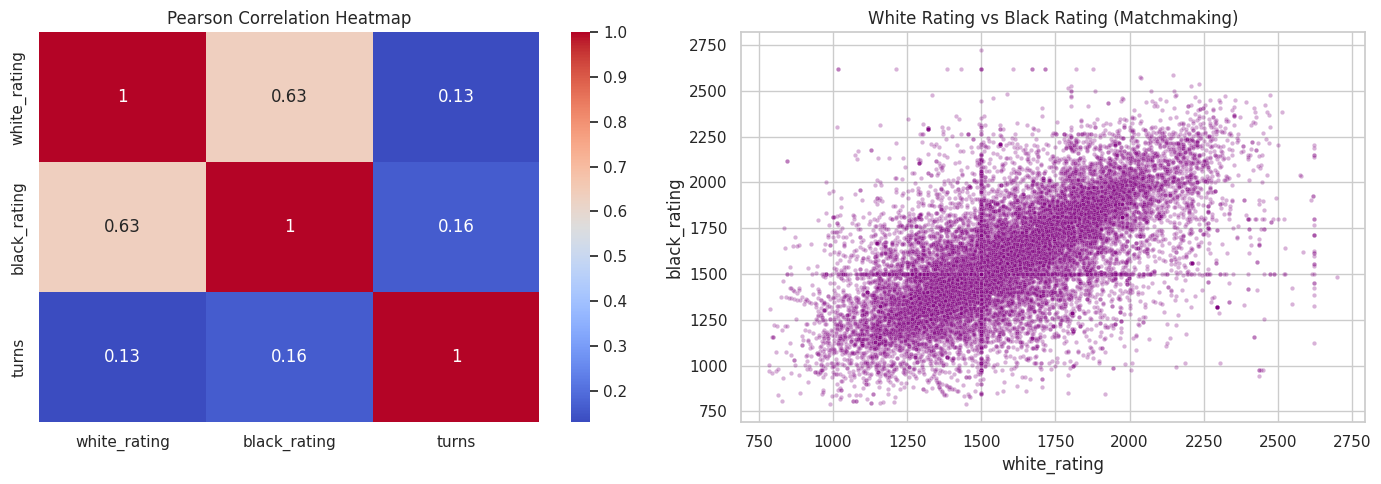

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Crosstab: Winner vs Victory Status ---")
display(pd.crosstab(df['winner'], df['victory_status']))

# סגנון הגרפים
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap
sns.heatmap(df[['white_rating', 'black_rating', 'turns']].corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Pearson Correlation Heatmap')

# 2. Scatterplot
sns.scatterplot(x='white_rating', y='black_rating', data=df, alpha=0.3, s=10, ax=axes[1], color='purple')
axes[1].set_title('White Rating vs Black Rating (Matchmaking)')

plt.tight_layout()
plt.show()

**6.3 Data Visualizations**
To truly understand the distributions and outliers, we visualized the data using multiple formats:
* **Histogram:** Shows the bell-curve distribution of player ratings.
* **Boxplot & Violin Plot:** Highlights the outliers in game length (`turns`) across different victory statuses.
* **Bar Chart (Countplot):** Displays the dominance of 'Resign' vs 'Mate'.

/tmp/ipykernel_4919/1089161369.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='victory_status', y='turns', data=df, ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_4919/1089161369.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='winner', y='turns', data=df, ax=axes[1, 1], palette='muted')


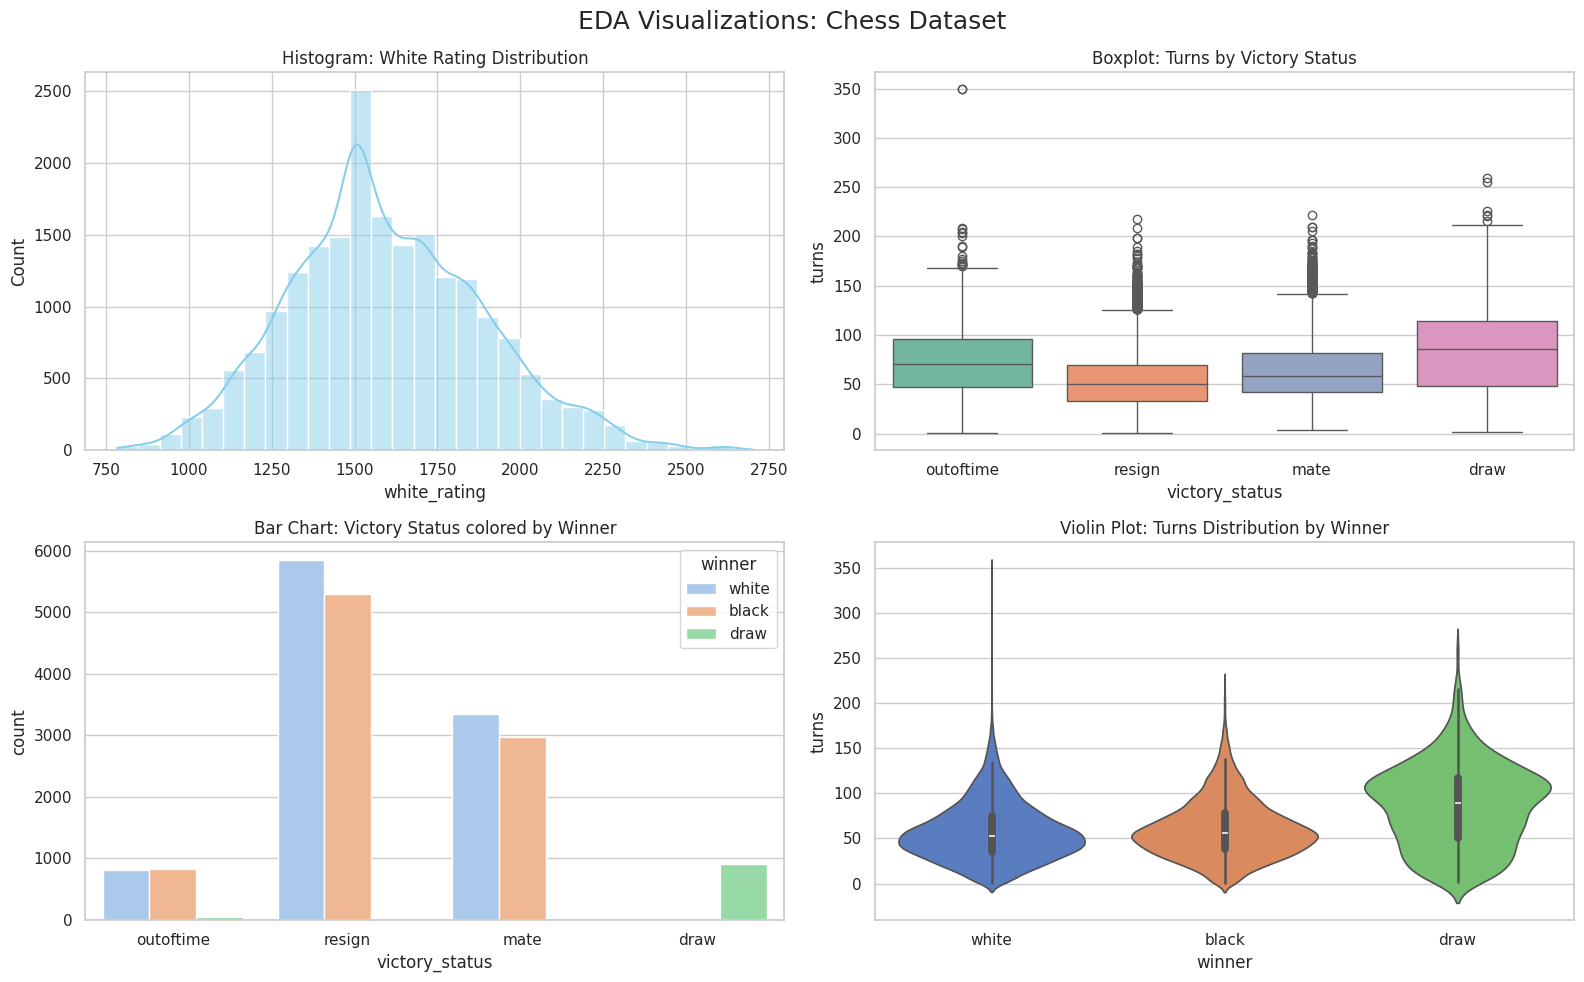

In [23]:
# יצירת לוח של 4 גרפים
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA Visualizations: Chess Dataset', fontsize=18)

# 1. Histogram
sns.histplot(df['white_rating'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Histogram: White Rating Distribution')

# 2. Boxplot
sns.boxplot(x='victory_status', y='turns', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Boxplot: Turns by Victory Status')

# 3. Bar Chart (Countplot)
sns.countplot(x='victory_status', hue='winner', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Bar Chart: Victory Status colored by Winner')

# 4. Violin Plot
sns.violinplot(x='winner', y='turns', data=df, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Violin Plot: Turns Distribution by Winner')

plt.tight_layout()
plt.show()

# **7. Index Analysis**

**Current Index Properties:**
* **Is it unique?** Yes. The default index is a Pandas `RangeIndex` (from 0 to 20,057), which guarantees uniqueness for every row.
* **Is it time-based?** No. The default index is purely numerical and represents the row number, carrying no chronological meaning.
* **Is it sorted?** The numerical index itself is sorted ascendingly. However, the underlying chess games are not strictly sorted by their actual playing time (`created_at`).

**Temporal Analysis (Changing the Index):**
To answer whether our analysis changes over time, we must set a time-based index. We converted the `created_at` timestamp into a proper Datetime format, set it as the new index, and sorted the DataFrame chronologically.
* **Does the analysis change over time?** By analyzing the average number of turns per month over time, we observe that the average game length fluctuates slightly but remains relatively stable, oscillating between 54 and 65 turns per game. This suggests that fundamental chess behavior on the platform (like game duration) is relatively stable and independent of the specific month it was played.

--- 7. Index Analysis ---
Is default index unique? True
Index type: <class 'pandas.core.indexes.base.Index'>
Is the data strictly sorted by time? False


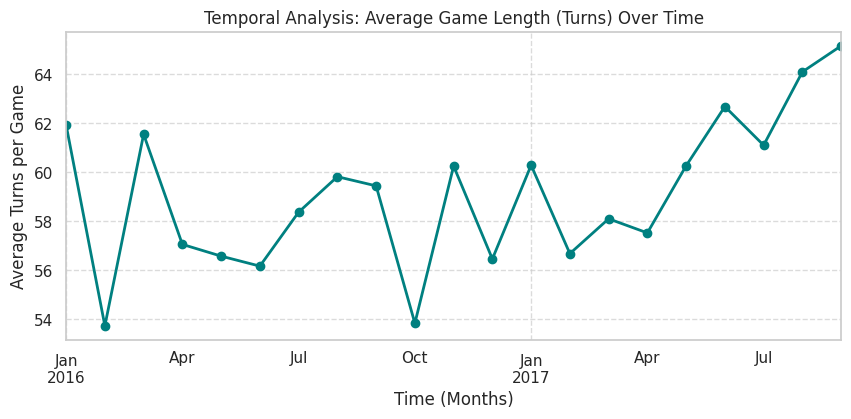

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- 7. Index Analysis ---")
print(f"Is default index unique? {df.index.is_unique}")
print(f"Index type: {type(df.index)}")

# נוודא שעמודת הזמן קיימת
if 'datetime' not in df.columns:
    df['datetime'] = pd.to_datetime(df['created_at'], unit='ms')

# האם הנתונים ממוינים כרונולוגית?
is_sorted_by_time = df['datetime'].is_monotonic_increasing
print(f"Is the data strictly sorted by time? {is_sorted_by_time}")

# יצירת דאטה-פריים חדש עם אינדקס מבוסס זמן
df_time = df.set_index('datetime').sort_index()

# רוב הנתונים במאגר הזה נאספו סביב 2016-2017.
# נסנן שגיאות הקלדה בשנים (outliers של תאריכים) ונבדוק ממוצע מהלכים לחודש
df_time_filtered = df_time[(df_time.index.year >= 2016) & (df_time.index.year <= 2017)]
monthly_turns = df_time_filtered['turns'].resample('ME').mean()

# נצייר את זה כדי לראות אם יש שינוי לאורך הזמן
plt.figure(figsize=(10, 4))
monthly_turns.plot(marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('Temporal Analysis: Average Game Length (Turns) Over Time')
plt.xlabel('Time (Months)')
plt.ylabel('Average Turns per Game')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **8. Insights and the Data Story**

**1. Main Insights:**
* **The Matchmaking Validation:** The extremely high correlation between opposing players' ratings proves the efficacy of the rating system. When structuring physical tournament brackets, seeding players purely by their Elo rating is a statistically sound method to ensure fair competition.
* **The First-Move Advantage:** The data empirically supports that playing White yields a higher win rate. This must be accounted for in Swiss-system tournament pairings, ensuring players alternate colors equally.
* **Endgame Etiquette:** As player ratings increase, the frequency of absolute checkmates tends to drop while resignations rise. This indicates a shift in player psychology and positional understanding at higher tiers.

**2. Points of Failure for ML Models:**
A machine learning model predicting the `winner` based solely on rating differences might fail spectacularly if it ignores the `time_control` variables. For example, a 2000-rated player might frequently lose to a 1500-rated player in 1-minute Bullet chess due to mouse-slips or time scrambles, an anomaly that the model would miss if it assumes classical chess conditions.

**3. Bias and Risk:**
The primary risk is **Format Bias**. Online data includes network disconnections, server lags, and pre-moving mechanics. Decisions regarding physical OTB (Over-The-Board) operations—such as allocating time-slots for physical venues—cannot rely entirely on online average game durations.

# **9. Bonus**

**9.1 Time Dependency & External Information**
The dataset contains timestamps (`created_at`). By converting these Unix timestamps to readable dates, we can extract external time-based features, such as the **Day of the Week**.
* **External Context:** In online gaming and physical tournament scheduling alike, weekend days (Saturday/Sunday) typically see a massive surge in casual play. We can analyze if game quality or lengths drop on weekends due to fatigue or the influx of amateur players.

**9.2 Feature Engineering**
We created two new features to enrich our dataset:
1. `datetime`: Converted the raw float timestamps into standard Python datetime objects.
2. `rating_diff`: Calculated the absolute difference between White and Black ratings (`abs(white_rating - black_rating)`). This creates a "Match Asymmetry" metric, which is critical for evaluating whether unequal pairings lead to faster games.

**9.3 Hypothesis Testing**
* **Null Hypothesis (H0):** There is no significant difference in the number of turns between High-Tier games (Average Rating > 2000) and Low-Tier games (Average Rating < 1500).
* **Alternative Hypothesis (H1):** High-Tier games have a significantly different number of turns compared to Low-Tier games.
* **Test:** We will use an Independent Two-Sample T-test.

**9.4 Proposals for Further Research**
1. **NLP on Chess Notation:** Apply Natural Language Processing (NLP) to the `moves` column to identify the frequency of specific tactical motifs (e.g., forks, pins) across different Elo brackets.
2. **Cheating Detection Models:** Analyze move times (if available in future datasets) against engine evaluations to detect anomalies indicative of computer assistance, a major issue in modern online chess.

In [17]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Feature Engineering: Time Conversion
# ממירים את חותמת הזמן ממילי-שניות לתאריך ושעה תקינים
df['datetime'] = pd.to_datetime(df['created_at'], unit='ms')
df['day_of_week'] = df['datetime'].dt.day_name()

# 2. Feature Engineering: New Metrics
# חישוב פער הדירוגים כדי לבדוק פערי רמות
df['rating_diff'] = abs(df['white_rating'] - df['black_rating'])
df['avg_rating'] = (df['white_rating'] + df['black_rating']) / 2

print("--- Feature Engineering Check ---")
display(df[['datetime', 'day_of_week', 'rating_diff', 'avg_rating']].head())

# 3. Hypothesis Testing (T-Test)
# חלוקה ל-2 קבוצות: שחקנים חזקים מול חלשים
high_tier_turns = df[df['avg_rating'] >= 2000]['turns']
low_tier_turns = df[df['avg_rating'] <= 1500]['turns']

t_stat, p_value = stats.ttest_ind(high_tier_turns, low_tier_turns, equal_var=False)

print("\n--- Hypothesis Testing: Game Length (High vs Low Tier) ---")
print(f"High-Tier Mean Turns: {high_tier_turns.mean():.2f}")
print(f"Low-Tier Mean Turns: {low_tier_turns.mean():.2f}")
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant difference in game lengths based on player skill tier.")
else:
    print("Conclusion: Fail to reject H0. No significant difference found.")

--- Feature Engineering Check ---


,datetime,day_of_week,rating_diff,avg_rating
0,2017-08-31 20:06:40,Thursday,309,1345.5
1,2017-08-30 21:53:20,Wednesday,61,1291.5
2,2017-08-30 21:53:20,Wednesday,4,1498.0
3,2017-08-30 16:20:00,Wednesday,15,1446.5
4,2017-08-29 18:06:40,Tuesday,54,1496.0



--- Hypothesis Testing: Game Length (High vs Low Tier) ---
High-Tier Mean Turns: 68.06
Low-Tier Mean Turns: 54.38
T-Statistic: 13.82
P-Value: 0.00000
Conclusion: Reject H0. There is a statistically significant difference in game lengths based on player skill tier.


/tmp/ipykernel_4919/564652031.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week', data=df, order=days_order, palette='magma')


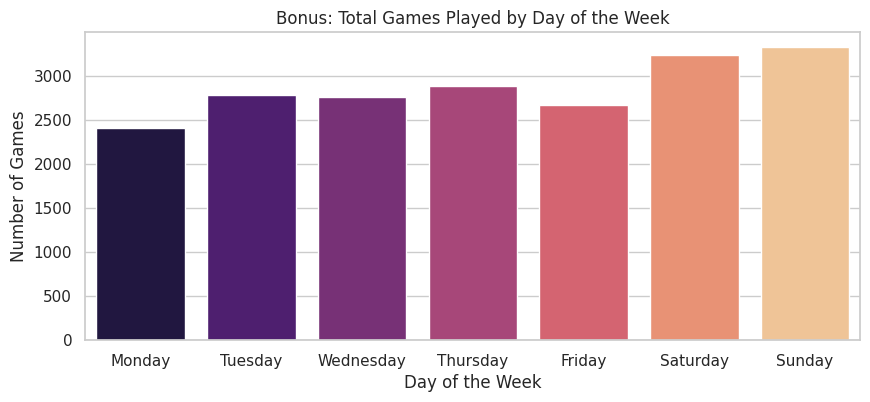

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. קודם נוודא שאנחנו מייצרים את עמודת ימי השבוע (למקרה שהיא לא קיימת)
if 'day_of_week' not in df.columns:
    df['datetime'] = pd.to_datetime(df['created_at'], unit='ms')
    df['day_of_week'] = df['datetime'].dt.day_name()

# 2. עכשיו כשהיא קיימת, נצייר את הגרף
plt.figure(figsize=(10, 4))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='day_of_week', data=df, order=days_order, palette='magma')
plt.title('Bonus: Total Games Played by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Games')
plt.show()

# **Epilogue: Learning Emphasis & Data Philosophy**

As stated in the course materials, data is not absolute "truth" but rather the product of a specific measurement process. Applying this critical lens to our Lichess dataset yields the following conclusions:

* **What is actually measured?** We are measuring server-side digital interactions. A "win" here includes victories by network disconnection, time expiration, or a physical mouse-slip. It measures *online platform performance*, which is a proxy for, but not perfectly identical to, pure intellectual chess skill.
* **What is missing?** Crucial metadata is absent. We lack the players' geographic locations, ages, physical conditions, and whether they were using external assistance (engine cheating). We also lack the granular time-control increments (e.g., distinguishing a 1-minute Bullet game from a 3-minute Blitz game clearly), which heavily dictates the number of blunders.
* **What is biased?** The dataset is inherently biased towards fast-paced, modern online chess culture. The frequency of aggressive, risky opening gambits is artificially inflated here compared to classical, slow-format physical tournaments.
* **What is artificially 'centered'?** The player rating distribution forms a perfect bell curve not by natural coincidence, but because the **Elo/Glicko rating mathematical formulas force it to center** (usually around 1500). The system is artificially designed to take points from the loser and give them to the winner, creating an artificial zero-sum gravitational pull toward the median.

By understanding these limitations, we ensure that any machine learning models or tournament systems built upon this data are robust, context-aware, and firmly grounded in reality.